### 1

In [11]:
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [12]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shubh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\shubh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shubh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shubh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [13]:
text_data = "Hello! this is an example Sentence,   Demonstrating text preprocessing in   NLP. running is a good exercise.  "

In [14]:
text_data = text_data.lower()
print("Lowercase Text : ", text_data)\

text_data = re.sub(r"[^a-zA-Z0-9\s]", "", text_data)
print("\nText Without Special Characters : ", text_data)

text_data = re.sub(r"\s+", " ", text_data).strip()
print("\nText Without Extra Spaces : ", text_data)

Lowercase Text :  hello! this is an example sentence,   demonstrating text preprocessing in   nlp. running is a good exercise.  

Text Without Special Characters :  hello this is an example sentence   demonstrating text preprocessing in   nlp running is a good exercise  

Text Without Extra Spaces :  hello this is an example sentence demonstrating text preprocessing in nlp running is a good exercise


In [15]:
tokens = word_tokenize(text_data)
print("Tokens : ", tokens)

Tokens :  ['hello', 'this', 'is', 'an', 'example', 'sentence', 'demonstrating', 'text', 'preprocessing', 'in', 'nlp', 'running', 'is', 'a', 'good', 'exercise']


In [16]:
stopwords = set(stopwords.words('english'))

tokens = [token for token in tokens if token not in stopwords]
print("Tokens Without Stopwords : ", tokens)

Tokens Without Stopwords :  ['hello', 'example', 'sentence', 'demonstrating', 'text', 'preprocessing', 'nlp', 'running', 'good', 'exercise']


In [18]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

PR_Stemmer = PorterStemmer()
text_stem = [PR_Stemmer.stem(token) for token in tokens]
print("Text After Stemming : ", text_stem)

WN_lemmatizer = WordNetLemmatizer()
text_lemmatize = [WN_lemmatizer.lemmatize(token) for token in tokens]
print("\nText After Lemmatization : ", text_lemmatize)

Text After Stemming :  ['hello', 'exampl', 'sentenc', 'demonstr', 'text', 'preprocess', 'nlp', 'run', 'good', 'exercis']

Text After Lemmatization :  ['hello', 'example', 'sentence', 'demonstrating', 'text', 'preprocessing', 'nlp', 'running', 'good', 'exercise']


### 2

In [22]:
str1 = str(input("Enter First String : "))
str2 = str(input("Enter Second String : "))

rows = len(str1)
cols = len(str2)

T = [[0 for j in range(cols+1)] for i in range(rows+1)]

for i in range(rows+1):
    T[i][0] = i

for j in range(cols+1):
    T[0][j] = j

for i in range(1, rows+1):
    for j in range(1, cols+1):
        if str1[i-1] == str2[i-1]:
            T[i][j] = T[i-1][j-1]
        else:
            T[i][j] = min(T[i-1][j-1], T[i][j-1], T[i-1][j]) + 1

i = rows
j = cols

op_count = {"Insert": 0, "Delete": 0, "Replace": 0}

while i > 0 and j > 0:
    if i > 0 and j > 0 and str1[i-1]==str2[j-1]:
        i -= 1
        j -= 1
    elif i > 0 and j > 0 and T[i][j] == T[i-1][j-1] + 1:
        op_count["Replace"] += 1
        i -= 1
        j -= 1
    elif i > 0 and T[i][j] == T[i-1][j] + 1:
        op_count["Delete"] += 1
        i -= 1
    else:
        op_count["Insert"] += 1
        j -= 1

print("\nEdit Distance Operations : ", T[rows][cols])
print("\nEdit Distance Matrix : \n")
for row in T:
    print(row)

print("\nTotal Operations : ")
for op, count in op_count.items():
    print(f"{op} : {count}")

Enter First String :  kitten
Enter Second String :  sitting



Edit Distance Operations :  3

Edit Distance Matrix : 

[0, 1, 2, 3, 4, 5, 6, 7]
[1, 1, 2, 3, 4, 5, 6, 7]
[2, 1, 1, 2, 3, 4, 5, 6]
[3, 2, 1, 1, 2, 3, 4, 5]
[4, 3, 2, 1, 1, 2, 3, 4]
[5, 4, 3, 2, 2, 2, 3, 4]
[6, 5, 4, 3, 2, 2, 2, 3]

Total Operations : 
Insert : 1
Delete : 0
Replace : 2


### 3

In [23]:
import nltk
import re
from nltk.tokenize import word_tokenize

In [24]:
text = "Time Flies"
text = text.lower()
text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
text = re.sub(r"\s+", " ", text).strip()
tokens = word_tokenize(text)

tags = ["N" , "V"]

pi ={"N": 0.6, "V": 0.4}

transition = {
    "N" : {"N": 0.3, "V": 0.7},
    "V" : {"N": 0.8, "V": 0.2}}

emission = {
    "N" : {"time": 0.5, "flies": 0.2},
    "V" : {"time": 0.1, "flies": 0.6}}

V = [{}]
path = {}

for state in tags:
    V[0][state] = pi[state] * emission[state][tokens[0]]
    path[state] = [state]

for t in range(1, len(tokens)):
    newpath = {}
    V.append({})
    for curr in tags:
        prob, state = max((V[t-1][prev] * transition[prev][curr] * emission[curr][tokens[t]], prev) for prev in tags)
        V[t][curr] = prob
        newpath[curr] = path[state] + [curr]
    path = newpath

prob, state = max((V[-1][state], state) for state in tags)

print("Best Sequence : ", path[state])
print("Probability : ", prob)

Best Sequence :  ['N', 'V']
Probability :  0.126


### 4

In [71]:
import pandas as pd 
import numpy as np

In [72]:
df = pd.read_csv(r"C:\Users\shubh\Downloads\NER dataset.csv", encoding="latin1") 
df

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,NaN,of,IN,O
2,NaN,demonstrators,NNS,O
3,NaN,have,VBP,O
4,NaN,marched,VBN,O
...,...,...,...,...
1048570,NaN,they,PRP,O
1048571,NaN,responded,VBD,O
1048572,NaN,to,TO,O
1048573,NaN,the,DT,O


In [73]:
df.isnull().sum() 

Sentence #    1000616
Word               10
POS                 0
Tag                 0
dtype: int64

In [75]:
df = df[['Sentence #', 'Word', 'POS']] 
df['Sentence #'] = df['Sentence #'].fillna(method='ffill') 

C:\Users\shubh\AppData\Local\Temp\ipykernel_12988\1585285877.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Sentence #'] = df['Sentence #'].fillna(method='ffill')


In [76]:
df.isnull().sum()

Sentence #     0
Word          10
POS            0
dtype: int64

In [77]:
df['Word'] = df['Word'].bfill()

In [78]:
sentences = df.groupby('Sentence #')['Word'].apply(list).values
pos_tags = df.groupby('Sentence #')['POS'].apply(list).values

In [79]:
sentences[0]

['Thousands',
 'of',
 'demonstrators',
 'have',
 'marched',
 'through',
 'London',
 'to',
 'protest',
 'the',
 'war',
 'in',
 'Iraq',
 'and',
 'demand',
 'the',
 'withdrawal',
 'of',
 'British',
 'troops',
 'from',
 'that',
 'country',
 '.']

In [80]:
pos_tags[0]

['NNS',
 'IN',
 'NNS',
 'VBP',
 'VBN',
 'IN',
 'NNP',
 'TO',
 'VB',
 'DT',
 'NN',
 'IN',
 'NNP',
 'CC',
 'VB',
 'DT',
 'NN',
 'IN',
 'JJ',
 'NNS',
 'IN',
 'DT',
 'NN',
 '.']

In [81]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [82]:
tokenizer = Tokenizer() 
tokenizer.fit_on_texts(sentences)

In [83]:
x = tokenizer.texts_to_sequences(sentences)

In [85]:
tag_tokenizer = Tokenizer() 
tag_tokenizer.fit_on_texts(pos_tags) 
y = tag_tokenizer.texts_to_sequences(pos_tags)

In [86]:
max_sentence_length= max([len(s) for s in sentences]) 
print(max_sentence_length)

104


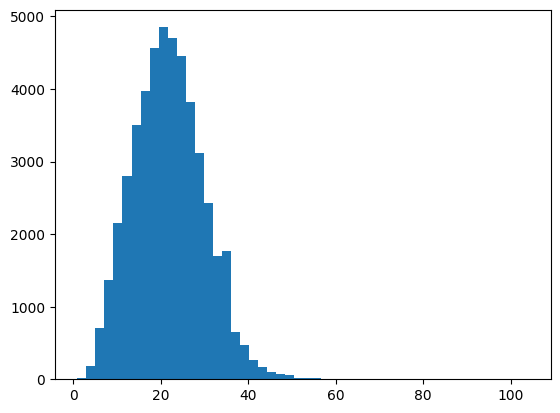

In [87]:
"""PADDING REQUIRED"""

import matplotlib.pyplot as plt 
plt.hist([len(sen) for sen in sentences], bins=50) 
plt.show()

In [88]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [89]:
MAX_LEN = 128 
x = pad_sequences(x, maxlen=MAX_LEN, padding='post') 
y = pad_sequences(y, maxlen=MAX_LEN, padding='post')

In [90]:
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8) 

In [91]:
"""LSTM MODEL"""
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, TimeDistributed

In [92]:
model = Sequential() 
model.add(Embedding(input_dim=len(tokenizer.word_index)+1, output_dim=64 )) 
model.add(LSTM(64, return_sequences=True)) 
model.add(TimeDistributed(Dense(len(tag_tokenizer.word_index)+1, activation='softmax' ))) 
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'] )

In [93]:
len(tokenizer.word_index)+1

31818

In [ ]:
model.fit(x_train, y_train, batch_size=32, epochs=5) 

In [ ]:
loss, acc = model.evaluate(x_test, y_test) 
print("Accuracy:", acc)

In [ ]:
sentence = sentences[0] 
seq = pad_sequences(tokenizer.texts_to_sequences([sentence]), maxlen=MAX_LEN, padding
pred = np.argmax(model.predict(seq), axis=-1)[0] 
index_to_tag = {v:k for k,v in tag_tokenizer.word_index.items()} 
for w, p in zip(sentence, pred): 
    print(w, "->", index_to_tag.get(p)) 

### 5

In [2]:
import re

text = """Ravi went to the market. He bought apples.
the boy was very happy because he found very fresh fruits."""

def extract_main_entity(text):
    words = text.split()
    for w in words:
        clean = w.strip(".,")
        if clean[0].isupper() and clean.lower() not in ["the", "a", "an"]:
            return clean
    return "Person"

main_entity = extract_main_entity(text)
resolved_text = text

references = [
    "the boy", "the girl", "the man", "the woman",
    "boy", "girl", "man", "woman",
    "he", "she", "him" "his", "her"]

for ref in references:
    pattern = r"\b" + ref + r"\b"
    resolved_text = re.sub(pattern, main_entity, resolved_text, flags=re.IGNORECASE)

print("Original Text : \n", text)
print("\nResolved Text : \n", resolved_text)

Original Text : 
 Ravi went to the market. He bought apples.
the boy was very happy because he found very fresh fruits.

Resolved Text : 
 Ravi went to the market. Ravi bought apples.
Ravi was very happy because Ravi found very fresh fruits.


### 6

In [9]:
"""SIMPLE LESK ALGORITHM"""

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk.wsd import lesk

In [10]:
sentence1 = "I went to the bank to deposit money"
tokens1 = word_tokenize(sentence1)
sense1 = lesk(tokens1, "bank", pos=wordnet.NOUN)

print("Sentence : ", sentence1)
print("Definition : ", sense1.definition())

Sentence :  I went to the bank to deposit money
Definition :  a financial institution that accepts deposits and channels the money into lending activities


In [11]:
sentence2 = "The river water overflowed the bank after heavy rain"
tokens2 = word_tokenize(sentence2)
sense2 = lesk(tokens2, "bank", pos=wordnet.NOUN)

print("Sentence : ", sentence2)
print("Definition : ", sense2.definition())

Sentence :  The river water overflowed the bank after heavy rain
Definition :  sloping land (especially the slope beside a body of water)


In [14]:
"""IMPROVED LESK ALGORITHM"""

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.corpus import wordnet

nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

stopwords = set(stopwords.words('english'))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\shubh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shubh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shubh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [18]:
def improved_lesk(sentence, word):
    context = set(word_tokenize(sentence.lower()))
    comtext = context - stopwords

    best_sense = None
    max_overlap = 0
    
    for sense in wordnet.synsets(word, pos=wordnet.NOUN):
        signature = word_tokenize(sense.definition().lower())

        for example in sense.examples():
            signature += word_tokenize(example.lower())

        signature = set(signature) - stopwords

        overlap = len(context.intersection(signature))

        if overlap > max_overlap:
            max_overlap = overlap
            best_sense = sense
    return best_sense

In [20]:
sentence1 = "I went to the bank to deposit money"
sentence2 = "The river water overflowed the bank after heavy rain"

sense1 = improved_lesk(sentence1, "bank")
sense2 = improved_lesk(sentence2, "bank")

print("Sentence : ", sentence1)
print("Definition : ", sense1.definition())
print("\nSentence : ", sentence2)
print("Definition : ", sense2.definition())

Sentence :  I went to the bank to deposit money
Definition :  a financial institution that accepts deposits and channels the money into lending activities

Sentence :  The river water overflowed the bank after heavy rain
Definition :  sloping land (especially the slope beside a body of water)


### 7

In [21]:
import json
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from gensim.models import Word2Vec, FastText

In [22]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shubh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shubh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
file_path = r"C:\Users\shubh\Downloads\Cell_Phones_and_Accessories_5.json"
reviews = []
with open(file_path, "r", encoding="utf-8") as f:
    for review in f:
        reviews.append(json.loads(review))

print("Total Reviews : ", len(reviews))

Total Reviews :  194439


In [24]:
stopwords = set(stopwords.words('english'))
sentences = []

for r in reviews:
    text = r.get("reviewText", "")
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token not in stopwords]

    if len(tokens) > 3:
        sentences.append(tokens)

print(sentences[0])

['look', 'good', 'stick', 'good', 'dont', 'like', 'rounded', 'shape', 'always', 'bumping', 'siri', 'kept', 'popping', 'irritating', 'wont', 'buy', 'product', 'like']


In [25]:
word2vec_model = Word2Vec(sentences=sentences)

In [26]:
word2vec_model.wv.most_similar("battery")

[('batter', 0.9084528684616089),
 ('batt', 0.8145982623100281),
 ('batterys', 0.7489131093025208),
 ('batteries', 0.7372806072235107),
 ('batterythe', 0.6673569083213806),
 ('batteryi', 0.6394111514091492),
 ('juice', 0.5860399603843689),
 ('batteryif', 0.5834918022155762),
 ('cycle', 0.5624427795410156),
 ('10k', 0.5410411357879639)]

In [27]:
word2vec_model.wv.similarity("movie","netflix")

np.float32(0.8951276)

In [28]:
fasttext_model = FastText(sentences=sentences)

In [29]:
fasttext_model.wv.most_similar("battery")

[('batterybattery', 0.9953329563140869),
 ('battery4', 0.9872502088546753),
 ('battery1', 0.9866614937782288),
 ('battery2', 0.9859985113143921),
 ('batterya', 0.9858084321022034),
 ('batterymy', 0.9856752157211304),
 ('battery3', 0.985344409942627),
 ('batteryno', 0.9844747185707092),
 ('batteryis', 0.9834725856781006),
 ('batteryso', 0.9823643565177917)]

In [30]:
fasttext_model.wv.similarity("movie","netflix")

np.float32(0.8479479)

### 8

In [9]:
import pandas as pd

In [10]:
df = pd.read_csv(r"C:\Users\shubh\Downloads\AG_News.csv")
df

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...
...,...,...,...
7595,1,Around the world,Ukrainian presidential candidate Viktor Yushch...
7596,2,Void is filled with Clement,With the supply of attractive pitching options...
7597,2,Martinez leaves bitter,Like Roger Clemens did almost exactly eight ye...
7598,3,5 of arthritis patients in Singapore take Bext...,SINGAPORE : Doctors in the United States have ...


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class Index  7600 non-null   int64 
 1   Title        7600 non-null   object
 2   Description  7600 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.3+ KB


In [12]:
df.describe()

,Class Index
count,7600.000000
mean,2.500000
std,1.118108
min,1.000000
25%,1.750000
50%,2.500000
75%,3.250000
max,4.000000


In [13]:
df.isnull().sum()

Class Index    0
Title          0
Description    0
dtype: int64

In [14]:
df['Description'] = df['Description'].str.lower()
df['Description'] = df['Description'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)
df['Description'] = df['Description'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [15]:
print(df['Description'])

0       unions representing workers at turner newall s...
1       spacecom toronto canada a secondteam of rocket...
2       ap a company founded by a chemistry researcher...
3       ap its barely dawn when mike fitzpatrick start...
4       ap southern californias smogfighting agency we...
                              ...                        
7595    ukrainian presidential candidate viktor yushch...
7596    with the supply of attractive pitching options...
7597    like roger clemens did almost exactly eight ye...
7598    singapore doctors in the united states have wa...
7599    ebay plans to buy the apartment and home renta...
Name: Description, Length: 7600, dtype: object


In [16]:
x = df['Description']
y = df['Class Index']

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()

x_vec = vectorizer.fit_transform(x)

In [18]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_vec, y, train_size=0.8)

In [19]:
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()

LR.fit(x_train, y_train)
y_pred_LR = LR.predict(x_test)

print("Accuracy : ", accuracy_score(y_test, y_pred_LR))
print("Classification Report : ", classification_report(y_test, y_pred_LR))

Accuracy :  0.8552631578947368
Classification Report :                precision    recall  f1-score   support

           1       0.90      0.86      0.88       387
           2       0.89      0.94      0.91       370
           3       0.83      0.82      0.82       386
           4       0.81      0.80      0.81       377

    accuracy                           0.86      1520
   macro avg       0.86      0.86      0.86      1520
weighted avg       0.86      0.86      0.85      1520



In [20]:
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier()

RF.fit(x_train, y_train)
y_pred_RF = RF.predict(x_test)

print("Accuracy : ", accuracy_score(y_test, y_pred_RF))
print("Classification Report : ", classification_report(y_test, y_pred_RF))

Accuracy :  0.7967105263157894
Classification Report :                precision    recall  f1-score   support

           1       0.84      0.77      0.80       387
           2       0.83      0.92      0.87       370
           3       0.81      0.75      0.78       386
           4       0.72      0.76      0.74       377

    accuracy                           0.80      1520
   macro avg       0.80      0.80      0.80      1520
weighted avg       0.80      0.80      0.80      1520



In [21]:
from sklearn.metrics import accuracy_score, classification_report

from sklearn.naive_bayes import MultinomialNB
NB = MultinomialNB()

NB.fit(x_train, y_train)
y_pred_NB = NB.predict(x_test)

print("Accuracy : ", accuracy_score(y_test, y_pred_NB))
print("Classification Report : ", classification_report(y_test, y_pred_NB))

Accuracy :  0.8638157894736842
Classification Report :                precision    recall  f1-score   support

           1       0.88      0.86      0.87       387
           2       0.90      0.97      0.94       370
           3       0.81      0.85      0.83       386
           4       0.87      0.78      0.82       377

    accuracy                           0.86      1520
   macro avg       0.86      0.86      0.86      1520
weighted avg       0.86      0.86      0.86      1520



### 9

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

In [23]:
red = pd.read_csv(r"C:\Users\shubh\Downloads\winequality-red.csv", sep=";")
white = pd.read_csv(r"C:\Users\shubh\Downloads\winequality-white.csv", sep=";")

In [24]:
red

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [25]:
white

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [26]:
df = pd.concat([red,white], axis=0)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 659.9 KB


In [28]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [29]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [30]:
x = df.drop('quality', axis=1)
y = df['quality']

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [32]:
linked = linkage(x_scaled, method='complete')

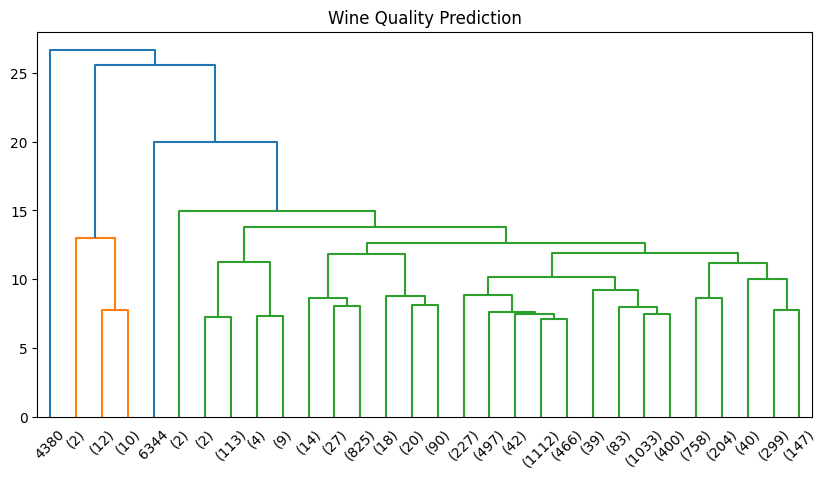

In [33]:
plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title("Wine Quality Prediction")
plt.show()

In [34]:
HC = AgglomerativeClustering(n_clusters=3)
df['cluster'] = HC.fit_predict(x_scaled)

In [35]:
print("Average Quality per Cluster")
print(df.groupby('cluster')['quality'].mean())

Average Quality per Cluster
cluster
0    5.602527
1    5.982084
2    5.625000
Name: quality, dtype: float64


### 10

In [53]:
import pandas as pd
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [54]:
df = pd.read_csv(r"C:\Users\shubh\Downloads\flipkart.csv")
df

,review,rating
0,It was nice produt. I like it's design a lot. ...,5
1,awesome sound....very pretty to see this nd th...,5
2,awesome sound quality. pros 7-8 hrs of battery...,4
3,I think it is such a good product not only as ...,5
4,awesome bass sound quality very good bettary l...,5
...,...,...
9971,GoodREAD MORE,5
9972,Everything is amazimg but the built is very li...,5
9973,GoodREAD MORE,5
9974,Best headphone i have ever used....READ MORE,5


In [55]:
df = df.drop('rating', axis=1)
df

,review
0,It was nice produt. I like it's design a lot. ...
1,awesome sound....very pretty to see this nd th...
2,awesome sound quality. pros 7-8 hrs of battery...
3,I think it is such a good product not only as ...
4,awesome bass sound quality very good bettary l...
...,...
9971,GoodREAD MORE
9972,Everything is amazimg but the built is very li...
9973,GoodREAD MORE
9974,Best headphone i have ever used....READ MORE


In [56]:
lemmatizer = WordNetLemmatizer()

In [57]:
def preprocess_review(text):
    if pd.isna(text):
        return ""
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = text.lower()
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in set(stopwords.words('english'))]

    return ' '.join(words)

In [58]:
df['clean_review'] = df['review'].apply(preprocess_review)
df

,review,clean_review
0,It was nice produt. I like it's design a lot. ...,nice produt like design lot easy carry looked ...
1,awesome sound....very pretty to see this nd th...,awesome sound pretty see nd sound quality good...
2,awesome sound quality. pros 7-8 hrs of battery...,awesome sound quality pro hr battery life incl...
3,I think it is such a good product not only as ...,think good product per quality also design qui...
4,awesome bass sound quality very good bettary l...,awesome bass sound quality good bettary long l...
...,...,...
9971,GoodREAD MORE,goodread
9972,Everything is amazimg but the built is very li...,everything amazimg built light read
9973,GoodREAD MORE,goodread
9974,Best headphone i have ever used....READ MORE,best headphone ever used read


In [59]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0.1:
        return "Positive"
    elif polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"

In [60]:
df['predicted_sentiment'] = df['clean_review'].apply(get_sentiment)
df

,review,clean_review,predicted_sentiment
0,It was nice produt. I like it's design a lot. ...,nice produt like design lot easy carry looked ...,Positive
1,awesome sound....very pretty to see this nd th...,awesome sound pretty see nd sound quality good...,Positive
2,awesome sound quality. pros 7-8 hrs of battery...,awesome sound quality pro hr battery life incl...,Positive
3,I think it is such a good product not only as ...,think good product per quality also design qui...,Positive
4,awesome bass sound quality very good bettary l...,awesome bass sound quality good bettary long l...,Positive
...,...,...,...
9971,GoodREAD MORE,goodread,Neutral
9972,Everything is amazimg but the built is very li...,everything amazimg built light read,Positive
9973,GoodREAD MORE,goodread,Neutral
9974,Best headphone i have ever used....READ MORE,best headphone ever used read,Positive


In [61]:
from rake_nltk import Rake
rake = Rake()

def extract_rake_keywords(text, top_n=5):
    rake.extract_keywords_from_text(text)
    keywords = rake.get_ranked_phrases()
    return keywords[:top_n]

In [62]:
df['rake_keywords'] = df['clean_review'].apply(extract_rake_keywords)
df

,review,clean_review,predicted_sentiment,rake_keywords
0,It was nice produt. I like it's design a lot. ...,nice produt like design lot easy carry looked ...,Positive,[nice produt like design lot easy carry looked...
1,awesome sound....very pretty to see this nd th...,awesome sound pretty see nd sound quality good...,Positive,[awesome sound pretty see nd sound quality goo...
2,awesome sound quality. pros 7-8 hrs of battery...,awesome sound quality pro hr battery life incl...,Positive,[awesome sound quality pro hr battery life inc...
3,I think it is such a good product not only as ...,think good product per quality also design qui...,Positive,[think good product per quality also design qu...
4,awesome bass sound quality very good bettary l...,awesome bass sound quality good bettary long l...,Positive,[awesome bass sound quality good bettary long ...
...,...,...,...,...
9971,GoodREAD MORE,goodread,Neutral,[goodread]
9972,Everything is amazimg but the built is very li...,everything amazimg built light read,Positive,[everything amazimg built light read]
9973,GoodREAD MORE,goodread,Neutral,[goodread]
9974,Best headphone i have ever used....READ MORE,best headphone ever used read,Positive,[best headphone ever used read]


In [63]:
from collections import Counter 
def top_preferences(sentiment, n=10): 
    keywords = [] 
    for kws in df[df['predicted_sentiment'] == sentiment]['rake_keywords']: 
        keywords.extend(kws) 
    return Counter(keywords).most_common(n) 

In [66]:
from wordcloud import WordCloud 
import matplotlib.pyplot as plt

def generate_wordcloud(keywords, title): 
    text = " ".join(keywords) 
    wc = WordCloud( 
        width=800, 
        height=400, 
        background_color="white" 
    ).generate(text) 
    
    plt.figure() 
    plt.imshow(wc, interpolation="bilinear") 
    plt.axis("off") 
    plt.title(title) 
    plt.show()

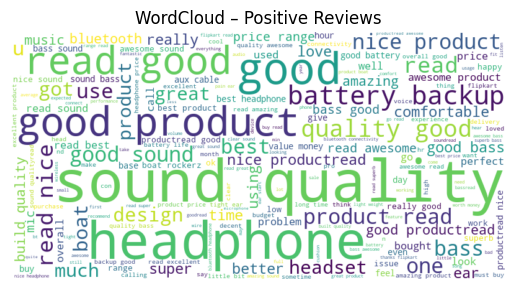

In [68]:
positive_keywords = [] 
for kws in df[df['predicted_sentiment'] == 'Positive']['rake_keywords']: 
    positive_keywords.extend(kws) 
    
generate_wordcloud(positive_keywords, "WordCloud – Positive Reviews")

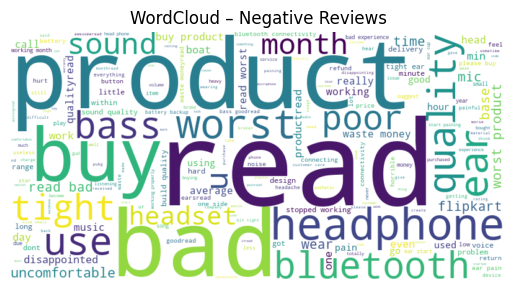

In [69]:
negative_keywords = [] 
for kws in df[df['predicted_sentiment'] == 'Negative']['rake_keywords']: 
    negative_keywords.extend(kws) 

generate_wordcloud(negative_keywords, "WordCloud – Negative Reviews")

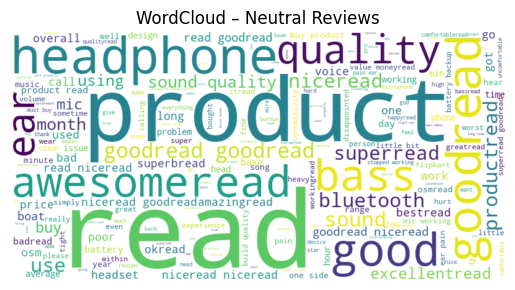

In [70]:
neutral_keywords = [] 
for kws in df[df['predicted_sentiment'] == 'Neutral']['rake_keywords']: 
    neutral_keywords.extend(kws) 

generate_wordcloud(neutral_keywords, "WordCloud – Neutral Reviews")